In [10]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TARGET_COL = "total_amount"

PROJECT_ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent]
DATA_CANDIDATES = [
    base / name
    for base in PROJECT_ROOT_CANDIDATES
    for name in [
        "my_clean_3_with_weather.parquet",
        "datasets/my_clean_3_with_weather.parquet",
        "datasets_local/my_clean_3_with_weather.parquet",
        "datasets/short_my_clean_3_with_weather.parquet",
        "datasets_local/short_my_clean_3_with_weather.parquet",
    ]
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)

if DATA_PATH is None:
    checked_paths = "\n".join(str(path) for path in DATA_CANDIDATES)
    raise FileNotFoundError(f"Dataset was not found. Checked paths:\n{checked_paths}")

PLOTS_DIR = Path("figures")
PLOTS_DIR.mkdir(exist_ok=True)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")


In [12]:
print("Loading latest dataset...")
df = pd.read_parquet(DATA_PATH)

df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")

# Keep only 2023-2024, just in case the file contains date outliers.
df = df.loc[
    df["tpep_pickup_datetime"].ge(pd.Timestamp("2023-01-01"))
    & df["tpep_pickup_datetime"].lt(pd.Timestamp("2025-01-01"))
].copy()

print("Shape:", df.shape)
print("Date range:", df["tpep_pickup_datetime"].min(), "-", df["tpep_pickup_datetime"].max())
print("Trips by year:")
print(df["tpep_pickup_datetime"].dt.year.value_counts().sort_index())
df.head()


Loading latest dataset...
Shape: (100000, 34)
Date range: 2023-01-01 00:01:58 - 2023-01-31 23:59:47
Trips by year:
tpep_pickup_datetime
2023    100000
Name: count, dtype: int64


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,DO_Borough,DO_Zone,DO_lon,DO_lat,distance_group,duration_min,temperature,precipitation,snowfall,weather_code
0,2,2023-01-29 17:52:02,2023-01-29 17:56:43,1,1.17,1.0,N,262,74,2,...,Manhattan,East Harlem North,-73.937346,40.801169,short,4.683333,9.6,0.0,0.0,3
1,1,2023-01-08 15:57:24,2023-01-08 16:02:47,1,0.90,1.0,N,229,237,2,...,Manhattan,Upper East Side South,-73.965635,40.768615,very_short,5.383333,4.2,0.0,0.0,3
2,2,2023-01-21 19:38:01,2023-01-21 19:45:02,1,0.95,1.0,N,45,261,1,...,Manhattan,World Trade Center,-74.013023,40.709139,very_short,7.016667,3.1,0.0,0.0,3
3,2,2023-01-23 16:07:31,2023-01-23 16:26:46,5,0.88,1.0,N,237,141,1,...,Manhattan,Lenox Hill West,-73.959635,40.766948,very_short,19.250000,2.9,0.6,0.0,53
4,2,2023-01-26 21:21:08,2023-01-26 21:24:48,2,1.03,1.0,N,229,140,1,...,Manhattan,Lenox Hill East,-73.954739,40.765484,short,3.666667,5.0,0.0,0.0,1


## 1.1 Useful charts for source data

These charts help check the trip price distribution, the relationship between price and distance, and time patterns before model training.

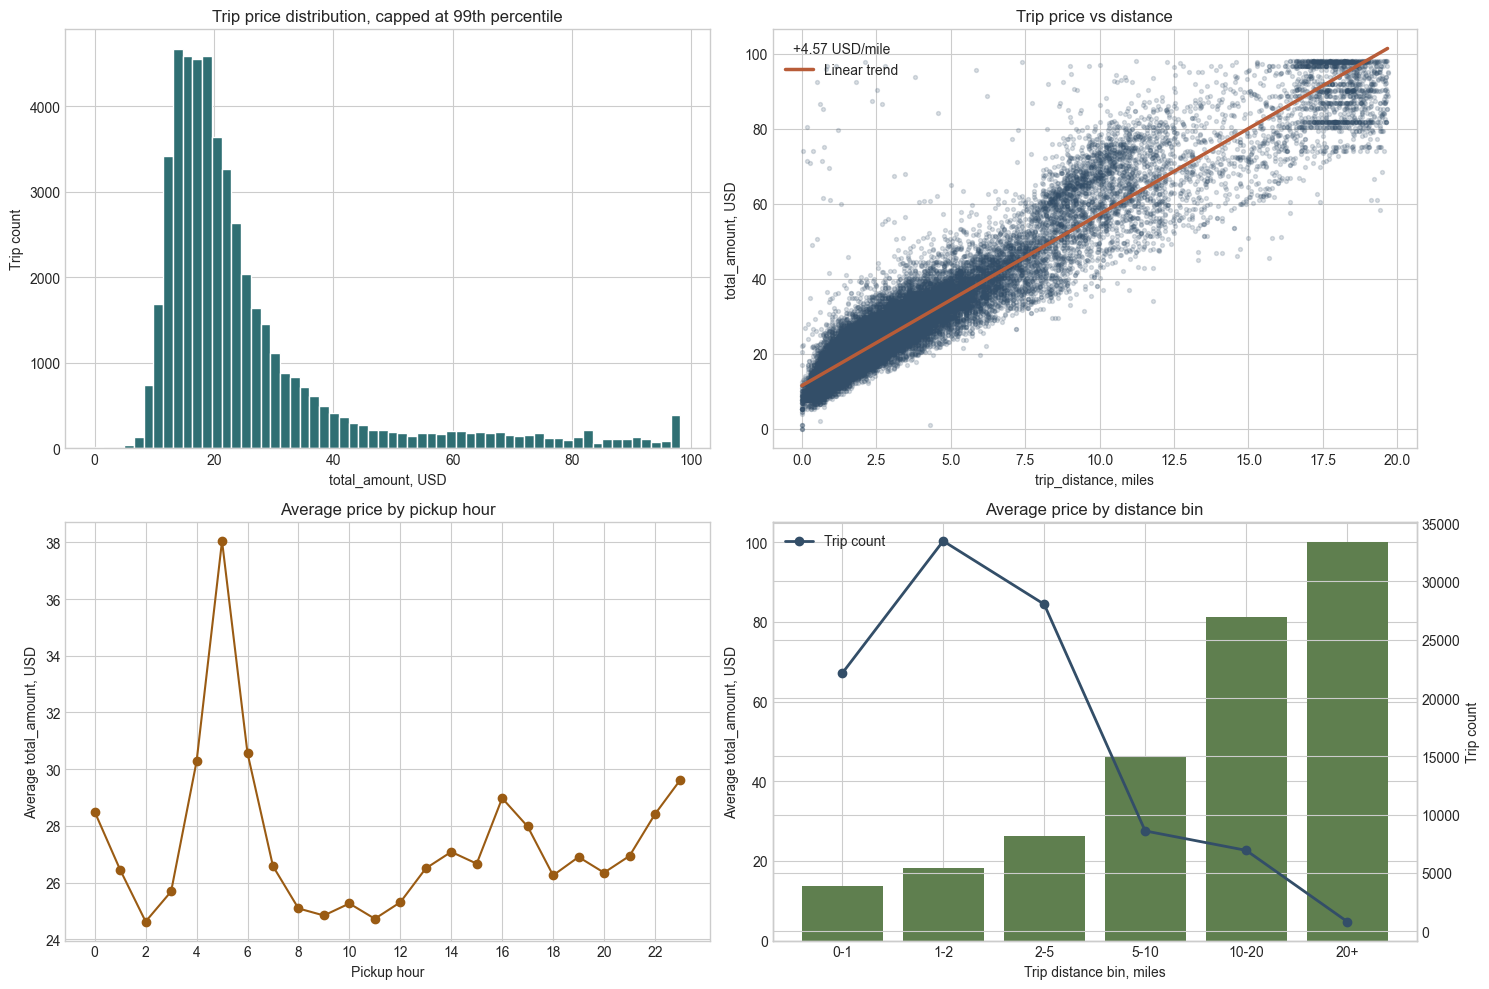

In [13]:
plot_df = df.copy()
plot_df["pickup_date"] = plot_df["tpep_pickup_datetime"].dt.date
plot_df["pickup_hour"] = plot_df["tpep_pickup_datetime"].dt.hour
plot_df["pickup_month"] = plot_df["tpep_pickup_datetime"].dt.to_period("M").astype(str)

price_cap = plot_df[TARGET_COL].quantile(0.99)
distance_cap = plot_df["trip_distance"].quantile(0.99)
plot_sample = plot_df.loc[
    plot_df[TARGET_COL].between(0, price_cap)
    & plot_df["trip_distance"].between(0, distance_cap)
].copy()
plot_sample = plot_sample.sample(min(50_000, len(plot_sample)), random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(plot_sample[TARGET_COL], bins=60, color="#2f6f73", edgecolor="white")
axes[0, 0].set_title("Trip price distribution, capped at 99th percentile")
axes[0, 0].set_xlabel("total_amount, USD")
axes[0, 0].set_ylabel("Trip count")

axes[0, 1].scatter(
    plot_sample["trip_distance"],
    plot_sample[TARGET_COL],
    s=8,
    alpha=0.18,
    color="#334e68",
)
line_x = np.linspace(plot_sample["trip_distance"].min(), plot_sample["trip_distance"].max(), 100)
line_coef = np.polyfit(plot_sample["trip_distance"], plot_sample[TARGET_COL], deg=1)
line_y = line_coef[0] * line_x + line_coef[1]
axes[0, 1].plot(line_x, line_y, color="#b85c38", linewidth=2.5, label="Linear trend")
axes[0, 1].legend(title=f"+{line_coef[0]:.2f} USD/mile", loc="upper left")
axes[0, 1].set_title("Trip price vs distance")
axes[0, 1].set_xlabel("trip_distance, miles")
axes[0, 1].set_ylabel("total_amount, USD")

hourly_price = plot_df.groupby("pickup_hour", observed=False)[TARGET_COL].mean()
axes[1, 0].plot(hourly_price.index, hourly_price.values, marker="o", color="#9a5b13")
axes[1, 0].set_title("Average price by pickup hour")
axes[1, 0].set_xlabel("Pickup hour")
axes[1, 0].set_ylabel("Average total_amount, USD")
axes[1, 0].set_xticks(range(0, 24, 2))

distance_bins = [0, 1, 2, 5, 10, 20, np.inf]
distance_labels = ["0-1", "1-2", "2-5", "5-10", "10-20", "20+"]
distance_stats = plot_df.assign(
    distance_bin=pd.cut(
        plot_df["trip_distance"],
        bins=distance_bins,
        labels=distance_labels,
        include_lowest=True,
    )
).groupby("distance_bin", observed=False).agg(
    avg_price=(TARGET_COL, "mean"),
    trips=(TARGET_COL, "size"),
).reset_index()

axes[1, 1].bar(distance_stats["distance_bin"].astype(str), distance_stats["avg_price"], color="#5f7f4f")
axes[1, 1].set_title("Average price by distance bin")
axes[1, 1].set_xlabel("Trip distance bin, miles")
axes[1, 1].set_ylabel("Average total_amount, USD")

count_axis = axes[1, 1].twinx()
count_axis.plot(
    distance_stats["distance_bin"].astype(str),
    distance_stats["trips"],
    color="#334e68",
    marker="o",
    linewidth=2,
    label="Trip count",
)
count_axis.set_ylabel("Trip count")
count_axis.legend(loc="upper left")

fig.tight_layout()
fig.savefig(PLOTS_DIR / "01_data_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("1. Building time, business, geo and weather features...")

model_df = df.copy()

# Fill low-cardinality categorical columns before splitting/features.
model_df["store_and_fwd_flag"] = model_df["store_and_fwd_flag"].fillna("unknown").astype(str)
model_df["distance_group"] = model_df["distance_group"].astype(str).replace("nan", "unknown")
model_df["PU_Borough"] = model_df["PU_Borough"].fillna("unknown").astype(str)
model_df["DO_Borough"] = model_df["DO_Borough"].fillna("unknown").astype(str)

model_df["pickup_hour"] = model_df["tpep_pickup_datetime"].dt.hour
model_df["pickup_dayofweek"] = model_df["tpep_pickup_datetime"].dt.dayofweek
model_df["pickup_month"] = model_df["tpep_pickup_datetime"].dt.month
model_df["pickup_day"] = model_df["tpep_pickup_datetime"].dt.day
model_df["pickup_weekofyear"] = model_df["tpep_pickup_datetime"].dt.isocalendar().week.astype(int)
model_df["is_weekend"] = model_df["pickup_dayofweek"].isin([5, 6]).astype(int)
model_df["is_rush_hour"] = (
    (model_df["pickup_dayofweek"] < 5)
    & (model_df["pickup_hour"] >= 16)
    & (model_df["pickup_hour"] < 20)
).astype(int)
model_df["is_night_tariff"] = ((model_df["pickup_hour"] >= 20) | (model_df["pickup_hour"] < 6)).astype(int)

model_df["hour_sin"] = np.sin(2 * np.pi * model_df["pickup_hour"] / 24)
model_df["hour_cos"] = np.cos(2 * np.pi * model_df["pickup_hour"] / 24)
model_df["dow_sin"] = np.sin(2 * np.pi * model_df["pickup_dayofweek"] / 7)
model_df["dow_cos"] = np.cos(2 * np.pi * model_df["pickup_dayofweek"] / 7)
model_df["month_sin"] = np.sin(2 * np.pi * model_df["pickup_month"] / 12)
model_df["month_cos"] = np.cos(2 * np.pi * model_df["pickup_month"] / 12)

model_df["lat_diff"] = (model_df["DO_lat"] - model_df["PU_lat"]).abs()
model_df["lon_diff"] = (model_df["DO_lon"] - model_df["PU_lon"]).abs()
model_df["gps_distance"] = model_df["lat_diff"] + model_df["lon_diff"]
model_df["distance_ratio"] = model_df["trip_distance"] / (model_df["gps_distance"] + 0.001)
model_df["distance_ratio"] = model_df["distance_ratio"].clip(0, 15)

model_df["duration_min"] = model_df["duration_min"].clip(lower=0.1)
model_df["speed_mph"] = model_df["trip_distance"] / (model_df["duration_min"] / 60 + 0.01)
model_df["speed_mph"] = model_df["speed_mph"].clip(0, 80)
model_df["log_trip_distance"] = np.log1p(model_df["trip_distance"])
model_df["log_duration_min"] = np.log1p(model_df["duration_min"])

model_df["has_precipitation"] = (model_df["precipitation"] > 0).astype(int)
model_df["has_snowfall"] = (model_df["snowfall"] > 0).astype(int)
model_df["bad_weather"] = ((model_df["precipitation"] > 0) | (model_df["snowfall"] > 0)).astype(int)
model_df["precipitation_x_rush_hour"] = model_df["precipitation"] * model_df["is_rush_hour"]
model_df["snowfall_x_rush_hour"] = model_df["snowfall"] * model_df["is_rush_hour"]

airport_zone_ids = {1, 132, 138}
model_df["pickup_airport"] = model_df["PULocationID"].isin(airport_zone_ids).astype(int)
model_df["dropoff_airport"] = model_df["DOLocationID"].isin(airport_zone_ids).astype(int)
model_df["airport_trip"] = ((model_df["pickup_airport"] == 1) | (model_df["dropoff_airport"] == 1)).astype(int)
model_df["same_zone"] = (model_df["PULocationID"] == model_df["DOLocationID"]).astype(int)
model_df["same_borough"] = (model_df["PU_Borough"] == model_df["DO_Borough"]).astype(int)
model_df["interborough_trip"] = (model_df["PU_Borough"] != model_df["DO_Borough"]).astype(int)

model_df["route_id"] = model_df["PULocationID"].astype(str) + "_" + model_df["DOLocationID"].astype(str)

print("Features created")


In [ ]:
categorical_cols = [
    "VendorID",
    "RatecodeID",
    "payment_type",
    "store_and_fwd_flag",
    "PU_Borough",
    "DO_Borough",
    "distance_group",
]

target_encoding_cols = [
    "PULocationID",
    "DOLocationID",
    "route_id",
    "RatecodeID",
]

target_encoded_feature_names = [
    "PU_zone_average_price",
    "DO_zone_average_price",
    "route_average_price",
    "ratecode_average_price",
]

weather_cols = [
    "temperature",
    "precipitation",
    "snowfall",
    "weather_code",
    "has_precipitation",
    "has_snowfall",
    "bad_weather",
    "precipitation_x_rush_hour",
    "snowfall_x_rush_hour",
]

time_cols = [
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "pickup_day",
    "pickup_weekofyear",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
]

trip_cols = [
    "trip_distance",
    "passenger_count",
    "is_weekend",
    "is_rush_hour",
    "is_night_tariff",
    "gps_distance",
    "distance_ratio",
    "duration_min",
    "speed_mph",
    "log_trip_distance",
    "log_duration_min",
    "pickup_airport",
    "dropoff_airport",
    "airport_trip",
    "same_zone",
    "same_borough",
    "interborough_trip",
]

numerical_cols = [
    *trip_cols,
    *time_cols,
    *weather_cols,
    *target_encoded_feature_names,
]

base_feature_cols = [
    "PULocationID",
    "DOLocationID",
    "route_id",
    "tpep_pickup_datetime",
    *categorical_cols,
    *[col for col in numerical_cols if col not in target_encoded_feature_names],
]

model_df = model_df.dropna(subset=[TARGET_COL, *base_feature_cols]).copy()
model_df = model_df.sort_values("tpep_pickup_datetime").reset_index(drop=True)

# Time split: train on earlier data, test on the latest months.
test_start = pd.Timestamp("2024-10-01")
train_mask = model_df["tpep_pickup_datetime"] < test_start
test_mask = model_df["tpep_pickup_datetime"] >= test_start

if test_mask.sum() == 0 or train_mask.sum() == 0:
    split_idx = int(len(model_df) * 0.8)
    train_mask = model_df.index < split_idx
    test_mask = model_df.index >= split_idx
    print("Fallback split: first 80% train, last 20% test")
else:
    print("Time split: train before", test_start.date(), "test from", test_start.date())

X_train_base = model_df.loc[train_mask, base_feature_cols].copy()
X_test_base = model_df.loc[test_mask, base_feature_cols].copy()
y_train = model_df.loc[train_mask, TARGET_COL].copy()
y_test = model_df.loc[test_mask, TARGET_COL].copy()

X_train_base = X_train_base.drop(columns=["tpep_pickup_datetime"])
X_test_base = X_test_base.drop(columns=["tpep_pickup_datetime"])

print("Train shape:", X_train_base.shape)
print("Test shape:", X_test_base.shape)
print("Train target mean:", round(y_train.mean(), 2))
print("Test target mean:", round(y_test.mean(), 2))


## 2.1 Train/test split check

These charts show whether target distributions in train and test are similar and whether the test period has a visible price shift.

In [ ]:
split_plot_df = pd.concat(
    [
        pd.DataFrame({"split": "train", TARGET_COL: y_train}),
        pd.DataFrame({"split": "test", TARGET_COL: y_test}),
    ],
    ignore_index=True,
)
price_cap_split = split_plot_df[TARGET_COL].quantile(0.99)
split_plot_df = split_plot_df[split_plot_df[TARGET_COL].between(0, price_cap_split)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for split_name, color in [("train", "#2f6f73"), ("test", "#b85c38")]:
    values = split_plot_df.loc[split_plot_df["split"] == split_name, TARGET_COL]
    axes[0].hist(values, bins=55, alpha=0.55, label=split_name, color=color, density=True)
axes[0].set_title("total_amount distribution in train and test")
axes[0].set_xlabel("total_amount, USD")
axes[0].set_ylabel("Density")
axes[0].legend()

monthly_target = model_df.assign(
    pickup_month=model_df["tpep_pickup_datetime"].dt.to_period("M").astype(str),
    split=np.where(train_mask, "train", "test"),
).groupby(["pickup_month", "split"], observed=False)[TARGET_COL].mean().reset_index()

for split_name, color in [("train", "#2f6f73"), ("test", "#b85c38")]:
    part = monthly_target[monthly_target["split"] == split_name]
    axes[1].plot(part["pickup_month"], part[TARGET_COL], marker="o", label=split_name, color=color)
axes[1].set_title("Average price by month in train/test")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average total_amount, USD")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

fig.tight_layout()
fig.savefig(PLOTS_DIR / "02_train_test_split.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
def add_target_encoding(train_x, test_x, train_y, source_cols, encoded_cols, smooth=50):
    train_x = train_x.copy()
    test_x = test_x.copy()
    global_mean = float(train_y.mean())

    train_with_target = train_x.copy()
    train_with_target[TARGET_COL] = train_y.values

    for source_col, encoded_col in zip(source_cols, encoded_cols):
        stats = train_with_target.groupby(source_col, observed=False)[TARGET_COL].agg(["mean", "count"])
        smoothed = (stats["mean"] * stats["count"] + global_mean * smooth) / (stats["count"] + smooth)
        train_x[encoded_col] = train_x[source_col].map(smoothed).fillna(global_mean).astype(float)
        test_x[encoded_col] = test_x[source_col].map(smoothed).fillna(global_mean).astype(float)

    return train_x, test_x

print("2. Adding smoothed train-only target encoding...")
X_train_full, X_test_full = add_target_encoding(
    X_train_base,
    X_test_base,
    y_train,
    target_encoding_cols,
    target_encoded_feature_names,
)

X_train = X_train_full[numerical_cols + categorical_cols].copy()
X_test = X_test_full[numerical_cols + categorical_cols].copy()

for col in categorical_cols:
    X_train[col] = X_train[col].astype("category")
    X_test[col] = X_test[col].astype("category")

print("Final feature count:", X_train.shape[1])
print("Final train shape:", X_train.shape)
print("Final test shape:", X_test.shape)


In [7]:
print("3. Training HistGradientBoostingRegressor...")

boosting_model = HistGradientBoostingRegressor(
    categorical_features="from_dtype",
    max_iter=900,
    max_leaf_nodes=127,
    learning_rate=0.015,
    min_samples_leaf=40,
    l2_regularization=0.01,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=30,
    random_state=42,
)

boosting_model.fit(X_train, y_train)
print("Boosting model trained")
print("Iterations used:", boosting_model.n_iter_)


3. Training HistGradientBoostingRegressor...
Boosting model trained
Iterations used: 900


In [8]:
print("4. Evaluating the boosting model...")

y_pred = boosting_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("================ BOOSTING METRICS ================")
print(f"MAE:  {mae:.2f} $")
print(f"RMSE: {rmse:.2f} $")
print(f"R2:   {r2 * 100:.1f}%")
print("==================================================")


4. Evaluating the boosting model...
================ BOOSTING METRICS ================
MAE:  1.84 $
RMSE: 3.80 $
R2:   96.8%


## 4.1 Test quality diagnostics

These charts help find systematic model errors: underprediction or overprediction, residual distribution, and error changes by pickup hour.

In [ ]:
diagnostics_df = X_test_base.copy()
diagnostics_df["pickup_datetime"] = model_df.loc[test_mask, "tpep_pickup_datetime"].values
diagnostics_df["y_true"] = y_test.values
diagnostics_df["y_pred"] = y_pred
diagnostics_df["residual"] = diagnostics_df["y_true"] - diagnostics_df["y_pred"]
diagnostics_df["abs_error"] = diagnostics_df["residual"].abs()
diagnostics_df["pickup_hour"] = diagnostics_df["pickup_datetime"].dt.hour
diagnostics_df["pickup_month"] = diagnostics_df["pickup_datetime"].dt.to_period("M").astype(str)

price_cap_diag = diagnostics_df[["y_true", "y_pred"]].quantile(0.99).max()
plot_diag = diagnostics_df[
    diagnostics_df["y_true"].between(0, price_cap_diag)
    & diagnostics_df["y_pred"].between(0, price_cap_diag)
].copy()
plot_diag = plot_diag.sample(min(50_000, len(plot_diag)), random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].scatter(plot_diag["y_true"], plot_diag["y_pred"], s=8, alpha=0.18, color="#334e68")
axes[0, 0].plot([0, price_cap_diag], [0, price_cap_diag], color="#b85c38", linewidth=2)
axes[0, 0].set_title("Actual vs predicted")
axes[0, 0].set_xlabel("Actual total_amount, USD")
axes[0, 0].set_ylabel("Prediction, USD")

residual_cap = diagnostics_df["residual"].abs().quantile(0.99)
axes[0, 1].hist(
    diagnostics_df["residual"].clip(-residual_cap, residual_cap),
    bins=70,
    color="#5f7f4f",
    edgecolor="white",
)
axes[0, 1].axvline(0, color="#222222", linewidth=1)
axes[0, 1].set_title("Residual distribution, capped at 99th percentile")
axes[0, 1].set_xlabel("y_true - y_pred, USD")
axes[0, 1].set_ylabel("Trip count")

axes[1, 0].scatter(plot_diag["y_pred"], plot_diag["residual"], s=8, alpha=0.18, color="#9a5b13")
axes[1, 0].axhline(0, color="#222222", linewidth=1)
axes[1, 0].set_title("Residuals vs prediction")
axes[1, 0].set_xlabel("Prediction, USD")
axes[1, 0].set_ylabel("Residual, USD")

hourly_error = diagnostics_df.groupby("pickup_hour", observed=False)["abs_error"].mean()
axes[1, 1].plot(hourly_error.index, hourly_error.values, marker="o", color="#2f6f73")
axes[1, 1].set_title("Average absolute error by pickup hour")
axes[1, 1].set_xlabel("Pickup hour")
axes[1, 1].set_ylabel("MAE, USD")
axes[1, 1].set_xticks(range(0, 24, 2))

fig.tight_layout()
fig.savefig(PLOTS_DIR / "03_model_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

## 4.2 Segment error analysis

Segment charts show where the model has higher error: boroughs, tariff codes, and weather conditions.

In [ ]:
segment_specs = [
    ("PU_Borough", "MAE by pickup borough"),
    ("DO_Borough", "MAE by dropoff borough"),
    ("RatecodeID", "MAE by rate code"),
    ("bad_weather", "MAE by weather flag"),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.ravel()

for ax, (col, title) in zip(axes, segment_specs):
    seg = (
        diagnostics_df.groupby(col, observed=False)
        .agg(mae=("abs_error", "mean"), trips=("abs_error", "size"))
        .query("trips >= 50")
        .sort_values("mae", ascending=False)
        .head(12)
        .sort_values("mae")
    )
    ax.barh(seg.index.astype(str), seg["mae"], color="#6b7f9c")
    ax.set_title(title)
    ax.set_xlabel("MAE, USD")
    ax.set_ylabel("")

fig.tight_layout()
fig.savefig(PLOTS_DIR / "04_segment_errors.png", dpi=150, bbox_inches="tight")
plt.show()

## 4.3 Permutation importance

This block calculates feature importance on a test subsample to keep the notebook fast. Higher values mean model quality drops more when that feature is shuffled.

In [ ]:
importance_sample_size = min(5_000, len(X_test))
importance_idx = X_test.sample(importance_sample_size, random_state=42).index

perm = permutation_importance(
    boosting_model,
    X_test.loc[importance_idx],
    y_test.loc[importance_idx],
    n_repeats=3,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=1,
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mae_increase": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mae_increase", ascending=False)

top_importance = importance_df.head(20).sort_values("importance_mae_increase")

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_importance["feature"], top_importance["importance_mae_increase"], color="#2f6f73")
ax.set_title("Top-20 features by permutation importance")
ax.set_xlabel("MAE increase after feature shuffle, USD")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(PLOTS_DIR / "05_permutation_importance.png", dpi=150, bbox_inches="tight")
plt.show()

importance_df.head(20)

In [ ]:
prediction_preview = pd.DataFrame({
    "y_true": y_test.reset_index(drop=True).head(20),
    "y_pred": pd.Series(y_pred).head(20),
})

prediction_preview["abs_error"] = (prediction_preview["y_true"] - prediction_preview["y_pred"]).abs()
prediction_preview
